# Week 5 - Maryi Tatiana Palacios Giraldo

In [6]:
import gymnasium as gym


In [8]:
!pip install torch

   ---------------------------------------- 0.0/241.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/241.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/241.2 MB 2.8 MB/s eta 0:01:26
   ---------------------------------------- 1.6/241.2 MB 2.7 MB/s eta 0:01:29
   ---------------------------------------- 2.1/241.2 MB 2.7 MB/s eta 0:01:28
   ---------------------------------------- 2.6/241.2 MB 2.7 MB/s eta 0:01:27
    --------------------------------------- 3.1/241.2 MB 2.8 MB/s eta 0:01:27
    --------------------------------------- 3.9/241.2 MB 2.7 MB/s eta 0:01:27
    --------------------------------------- 4.5/241.2 MB 2.7 MB/s eta 0:01:28
    --------------------------------------- 5.0/241.2 MB 2.7 MB/s eta 0:01:27
    --------------------------------------- 5.5/241.2 MB 2.7 MB/s eta 0:01:27
    --------------------------------------- 6.0/241.2 MB 2.7 MB/s eta 0:01:29
   - -------------------------------------- 6.3/241.2 MB 2.6 MB/s eta 0:01:29



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

## Policy Network

In [10]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        logits = self.fc3(x)
        return logits

## Value Network

In [11]:
class ValueNetwork(nn.Module):
    def __init__(self, state_dim):
        super(ValueNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        value = self.fc3(x)
        return value

# Action Selection

In [12]:
def select_action(policy_net, state):
    state = torch.tensor(state, dtype=torch.float32)
    logits = policy_net(state)
    probs = F.softmax(logits, dim=-1)
    dist = torch.distributions.Categorical(probs)
    
    action = dist.sample()
    log_prob = dist.log_prob(action)
    
    return action.item(), log_prob

## (G_t)

In [13]:
def compute_returns(rewards, gamma=0.99):
    returns = []
    G = 0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    return torch.tensor(returns, dtype=torch.float32)

## Training

In [ ]:
def train_reinforce(env, policy_net, value_net=None, episodes=1000, gamma=0.99):
    optimizer_policy = optim.Adam(policy_net.parameters(), lr=1e-3)
    
    if value_net:
        optimizer_value = optim.Adam(value_net.parameters(), lr=1e-3)

    all_returns = []

    for episode in range(episodes):
        state, _ = env.reset()
        
        log_probs = []
        rewards = []
        states = []

        done = False
        
        while not done:
            action, log_prob = select_action(policy_net, state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            
            log_probs.append(log_prob)
            rewards.append(reward)
            states.append(state)

            state = next_state
            done = terminated or truncated

        returns = compute_returns(rewards, gamma)

        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        policy_loss = []
        value_loss = []

        for log_prob, G, state in zip(log_probs, returns, states):
            state_tensor = torch.tensor(state, dtype=torch.float32)

            if value_net:
                baseline = value_net(state_tensor)
                advantage = G - baseline.item()

                value_loss.append((baseline - G)**2)
            else:
                advantage = G

            policy_loss.append(-log_prob * advantage)

        optimizer_policy.zero_grad()
        torch.stack(policy_loss).sum().backward()
        optimizer_policy.step()

        if value_net:
            optimizer_value.zero_grad()
            torch.stack(value_loss).sum().backward()
            optimizer_value.step()

        total_return = sum(rewards)
        all_returns.append(total_return)

        if episode % 100 == 0:
            print(f"Episode {episode}, Return: {total_return}")

    return all_returns

In [15]:
env = gym.make("CartPole-v1")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

policy_net = PolicyNetwork(state_dim, action_dim)
returns_reinforce = train_reinforce(env, policy_net)

policy_net2 = PolicyNetwork(state_dim, action_dim)
value_net = ValueNetwork(state_dim)
returns_baseline = train_reinforce(env, policy_net2, value_net)

Episode 0, Return: 19.0
Episode 100, Return: 154.0
Episode 200, Return: 128.0
Episode 300, Return: 74.0
Episode 400, Return: 500.0
Episode 500, Return: 500.0
Episode 600, Return: 170.0
Episode 700, Return: 500.0
Episode 800, Return: 500.0
Episode 900, Return: 500.0
Episode 0, Return: 25.0
Episode 100, Return: 46.0
Episode 200, Return: 500.0
Episode 300, Return: 500.0
Episode 400, Return: 500.0
Episode 500, Return: 154.0
Episode 600, Return: 131.0
Episode 700, Return: 137.0
Episode 800, Return: 500.0
Episode 900, Return: 500.0


The learning curves show high variance in early training, which is expected in REINFORCE due to Monte Carlo return estimation. However, both runs eventually converge to near-optimal performance (return ≈ 500), indicating that the policy successfully learns a stable control strategy.
These fluctuations highlight the inherent variance in Monte Carlo policy gradient methods, where updates depend on complete episode returns rather than bootstrapped estimates.

In [16]:
torch.save(policy_net.state_dict(), "policy.pth")

## Set Random Seed for Reproducibility

In [17]:
def set_seed(seed):
    import random
    import numpy as np
    import torch
    
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

In [18]:
num_seeds = 5
all_returns_reinforce = []
all_returns_baseline = []

for seed in range(num_seeds):
    set_seed(seed)
    
    env = gym.make("CartPole-v1")
    
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    policy_net = PolicyNetwork(state_dim, action_dim)
    returns_r = train_reinforce(env, policy_net)
    all_returns_reinforce.append(returns_r)

    policy_net_b = PolicyNetwork(state_dim, action_dim)
    value_net = ValueNetwork(state_dim)
    returns_b = train_reinforce(env, policy_net_b, value_net)
    all_returns_baseline.append(returns_b)

Episode 0, Return: 20.0
Episode 100, Return: 90.0
Episode 200, Return: 314.0
Episode 300, Return: 500.0
Episode 400, Return: 230.0
Episode 500, Return: 500.0
Episode 600, Return: 263.0
Episode 700, Return: 500.0
Episode 800, Return: 500.0
Episode 900, Return: 500.0
Episode 0, Return: 18.0
Episode 100, Return: 25.0
Episode 200, Return: 149.0
Episode 300, Return: 142.0
Episode 400, Return: 500.0
Episode 500, Return: 369.0
Episode 600, Return: 500.0
Episode 700, Return: 500.0
Episode 800, Return: 500.0
Episode 900, Return: 146.0
Episode 0, Return: 28.0
Episode 100, Return: 26.0
Episode 200, Return: 242.0
Episode 300, Return: 141.0
Episode 400, Return: 158.0
Episode 500, Return: 500.0
Episode 600, Return: 500.0
Episode 700, Return: 500.0
Episode 800, Return: 132.0
Episode 900, Return: 500.0
Episode 0, Return: 33.0
Episode 100, Return: 207.0
Episode 200, Return: 214.0
Episode 300, Return: 500.0
Episode 400, Return: 500.0
Episode 500, Return: 500.0
Episode 600, Return: 500.0
Episode 700, Ret

## Performance Aggregation Over Multiple Seeds

In [23]:
import numpy as np

reinforce_runs = np.array(all_returns_reinforce)
baseline_runs = np.array(all_returns_baseline)

In [24]:
reinforce_mean = reinforce_runs.mean(axis=0)
reinforce_std = reinforce_runs.std(axis=0)

baseline_mean = baseline_runs.mean(axis=0)
baseline_std = baseline_runs.std(axis=0)

## Visualizations

## Learning Curves (Mean)

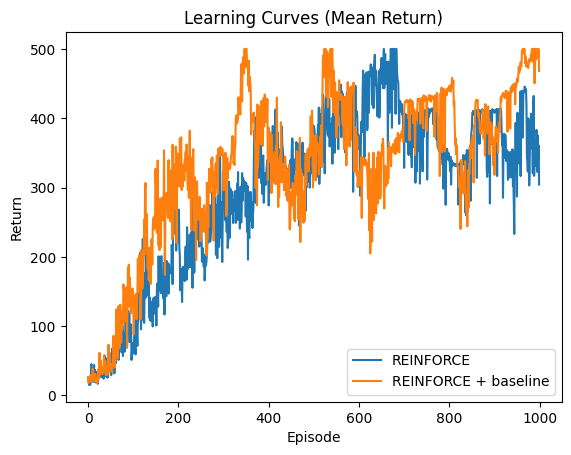

In [25]:
import matplotlib.pyplot as plt

episodes = range(len(reinforce_mean))

plt.plot(episodes, reinforce_mean, label="REINFORCE")
plt.plot(episodes, baseline_mean, label="REINFORCE + baseline")

plt.title("Learning Curves (Mean Return)")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()
plt.show()

Both methods show a clear upward trend in returns over time, indicating that both policies successfully learn to balance the CartPole environment. Early in training, both algorithms exhibit high variance and unstable performance, which is expected due to random exploration and untrained policies.

REINFORCE + baseline tends to reach higher and more stable performance earlier in training compared to standard REINFORCE. This suggests that the baseline reduces variance in the gradient updates, allowing for more consistent policy improvement.

However, both methods eventually converge to similar performance levels, showing that the baseline does not change the optimal policy, but improves the learning dynamics.

## Confidence Intervals (Mean ± Std)

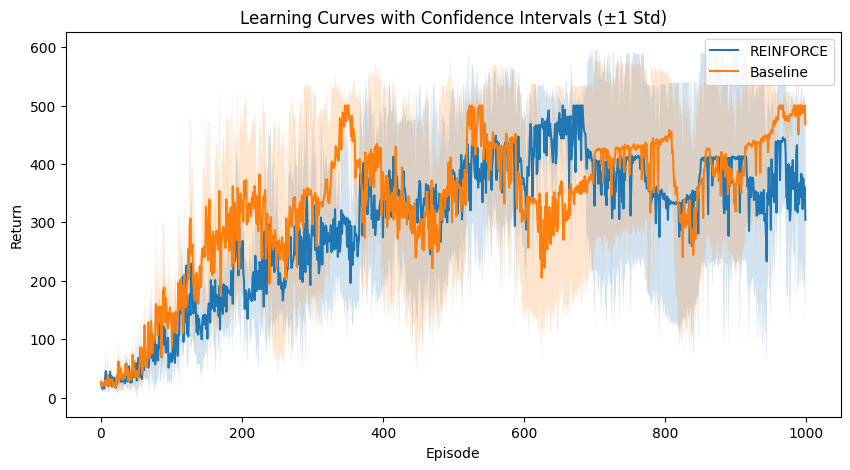

In [26]:
plt.figure(figsize=(10,5))

plt.plot(episodes, reinforce_mean, label="REINFORCE")
plt.fill_between(
    episodes,
    reinforce_mean - reinforce_std,
    reinforce_mean + reinforce_std,
    alpha=0.2
)

plt.plot(episodes, baseline_mean, label="Baseline")
plt.fill_between(
    episodes,
    baseline_mean - baseline_std,
    baseline_mean + baseline_std,
    alpha=0.2
)

plt.title("Learning Curves with Confidence Intervals (±1 Std)")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()
plt.show()

This plot highlights the variability of policy gradient methods across different random seeds. REINFORCE shows significantly wider confidence intervals, especially in early and mid training stages, indicating high variance in gradient estimation.

In contrast, REINFORCE with baseline exhibits noticeably tighter confidence intervals, demonstrating reduced variance across runs. This confirms the theoretical role of the baseline as a variance reduction technique, as described in Sutton & Barto (Chapter 13).

Even though both methods reach similar performance levels, the baseline method achieves more stable and consistent learning trajectories across different initializations.

## Comparison Plot (Final Performance)

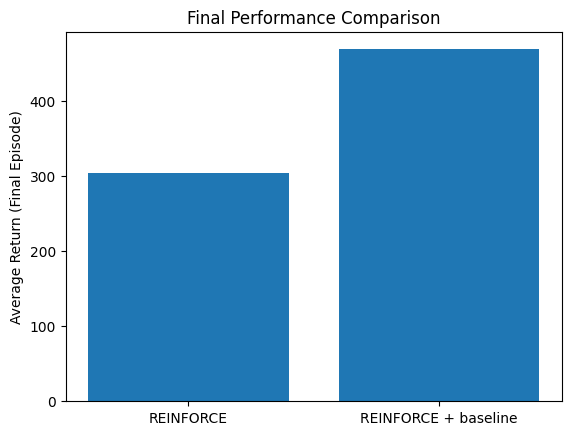

In [27]:
plt.bar(
    ["REINFORCE", "REINFORCE + baseline"],
    [reinforce_mean[-1], baseline_mean[-1]]
)

plt.title("Final Performance Comparison")
plt.ylabel("Average Return (Final Episode)")
plt.show()

The final performance comparison shows that REINFORCE with baseline achieves a higher average return at the end of training compared to standard REINFORCE.

This indicates that reducing variance not only stabilizes learning but can also improve final performance within a fixed training budget. REINFORCE appears more sensitive to randomness and may require more episodes or tuning to reach similar performance.

Overall, the baseline improves learning efficiency by producing more reliable gradient estimates.

## Conclusion

The results confirm that both REINFORCE and REINFORCE with baseline converge to effective policies in the CartPole environment. However, the baseline method significantly improves training stability by reducing variance in policy gradient estimates. This is consistent with Sutton & Barto (Chapter 13), which states that baselines reduce variance without introducing bias, leading to more stable and efficient learning.